In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

## Exploring the use of autograd to fit SDDE models to data

Let's consider a simple stochastic model of the segmentation clock:

$dH_t = \left(\frac{r}{1 + (H_{t-\tau}/K_D)^n} -\gamma H\right)dt + \sigma \sqrt{H_t} dW_t$

with initial history

$H_t = 0$ for $t \leq 0$

### Differentiable numerical solution to an SDDE

Our approach combines the following ingredients:

1) A modified Milstein algorithm with manually-enforced non-negativity:

$H_{n+1} = \text{max}\left(H_n + a(H)dt + b(H_n)dW_n + \frac{1}{2}b(H_n)b'(H_n)\left((\Delta W_n)^2 - \Delta t\right), 0\right)$

with $a(H) = \left(\frac{r}{1 + (H(t-\tau)/K_D)^n} -\gamma H\right)$ and $b(H) = \sigma \sqrt{H}$.

2) A piecewise-differentiable, linear interpolation of the delay:
Let $d = \tau / dt$ represent the delay in units of fractional timesteps. We write

$d = k + \alpha$,

with $k = \text{floor}(d)$.

Then we interpolate using

$H_{delayed} = (1- \alpha)H_k + \alpha H_{k+1}$.

In [2]:
torch.set_default_device('cuda')

In [3]:
torch.autograd.set_detect_anomaly(False)

In [4]:
EPS = 1e-8

In [5]:
def solve_sde(t_max=10.0, r=10.0, gamma=0.23, KD=10.0, n=2, tau=7.0, sigma=0.1, dt=0.01, num_replicates=1):
    """solve sde using the Milstein method"""
    t_arr = torch.arange(0, t_max, dt)
    H_arr = torch.zeros((len(t_arr), num_replicates))
    delay = int(tau / dt)
    dWt = np.sqrt(dt) * torch.randn(size=(len(t_arr), num_replicates))
    for i in range(1, len(t_arr)):
        delayed_index = i - delay if i - delay > 0 else 0
        new_H = H_arr[i - 1] + drift(H_arr[i-1], H_arr[delayed_index], r, gamma, KD, n) * dt + diffusion(H_arr[i-1], sigma) * dWt[i-1] + second_order_term(sigma) * (dWt[i-1] ** 2 - dt) 
        H_arr[i] = torch.clamp(new_H, min=0)
        
    return H_arr

def solve_sde_for_optimization(t_max=10.0, r=10.0, gamma=0.23, KD=0.1, n=2, tau=1.0, sigma=0.1, dt=0.01, num_replicates=1):
    """solve sde using the Milstein method, but make it friendly to autograd by avoiding in place modifications"""
    # instead of an array, we will just append to a list
    H_list = []
    H = torch.zeros(num_replicates)
    H_list.append(H)
    t_arr = torch.arange(0, t_max, dt)

    #delay = int(tau / dt)
    delay_steps = tau / dt
    k = torch.floor(delay_steps).long()
    alpha = delay_steps - k
    
    dWt = np.sqrt(dt) * torch.randn(size=(len(t_arr), num_replicates))
    for i in range(1, len(t_arr)):
        # linearly interpolate between adjacent discrete timepoints for the delay
        if i - k.item() <= 0:
            delayed_H = H_list[0]
        else:
            H_later = H_list[i - k.item()]
            H_earlier = H_list[i - k.item() - 1]

            delayed_H = (
                (1 - alpha) * H_later
                + alpha * H_earlier
            )
        H = H + drift(H, delayed_H, r, gamma, KD, n) * dt + diffusion(H, sigma) * dWt[i-1] + second_order_term(sigma) * (dWt[i-1] ** 2 - dt) 
        H = torch.clamp(H, min=0)
        H_list.append(H)
        
    return torch.stack(H_list)

def drift(H, H_delayed, r, gamma, KD, n):
    return r / (1 + (H_delayed / KD) ** n) - gamma * H

def diffusion(H, sigma):
    return sigma * torch.sqrt(H + EPS)

def second_order_term(sigma):
    # second order term of Milstein solution
    return 0.25 * sigma ** 2
    
def loss_function(mean_final_state, variance, target_mean, target_std):
    """
    Calculates the mean squared error of the simulation results against data
    """
    return (mean_final_state - target_mean) ** 2 + (variance ** 0.5 - target_std) ** 2

def cv2_loss(cv2, target_cv2):
    """
    fit the cv2
    """
    return (cv2 - target_cv2) ** 2 

def mean_var_autocorr_loss(mean_final_state, variance, corr, target_mean, target_std, target_corr, lam):
    """
    Calculates the mean squared error of the simulation results against data
    """
    return (mean_final_state - target_mean) ** 2 + (variance ** 0.5 - target_std) ** 2 + lam * torch.sum((corr - target_corr) ** 2)

def autocorr(x, lags):
    corr = []
    for i in range(len(lags)):
        l = lags[i]
        if l == 0:
            corr.append(torch.ones(x.shape[1]))
        else:
            a = x[l:]
            b = x[:-l]
            corr.append((torch.mean(a * b, axis=0) - torch.mean(a, axis=0) * torch.mean(b, axis=0)) / torch.std(a, axis=0) / torch.std(b, axis=0))

    return torch.stack(corr)

### Run one simulation

In [5]:
t_max = 100.0
r = 10.0
gamma = 0.23
KD = 10.0
n = 2.0
tau = 7.0
sigma = 2.0
dt = 0.1
num_replicates = 1
H_arr = solve_sde(t_max=t_max, r=r, gamma=gamma, KD=KD, n=n, tau=tau, sigma=sigma, dt=dt, num_replicates=num_replicates)
#H_arr = solve_sde_for_optimization(t_max=t_max, KD=KD, n=n, tau=tau, sigma=sigma, dt=dt, num_replicates=num_replicates)

Text(0, 0.5, '$H$')

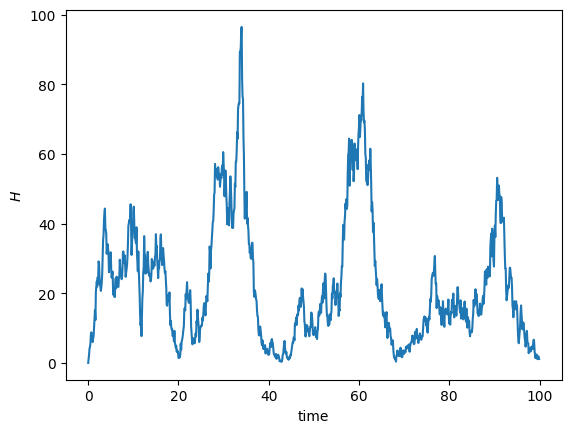

In [7]:
t_arr = torch.arange(0, t_max, dt)
plt.figure()
plt.plot(t_arr, H_arr
plt.xlabel('time')
plt.ylabel('$H$')

### Generate ground truth data

In [6]:
t_max = 100.0
r = 10.0
gamma = 0.23
KD = 10.0
n = 2.0
tau = 7.0
sigma = 2.0
dt = 0.1

num_replicates = 100000#0
H_arr_truth = solve_sde(t_max=t_max, KD=KD, n=n, tau=tau, sigma=sigma, dt=dt, num_replicates=num_replicates)
final_Hs_truth = H_arr_truth[-1]


Text(0, 0.5, 'P(H)')

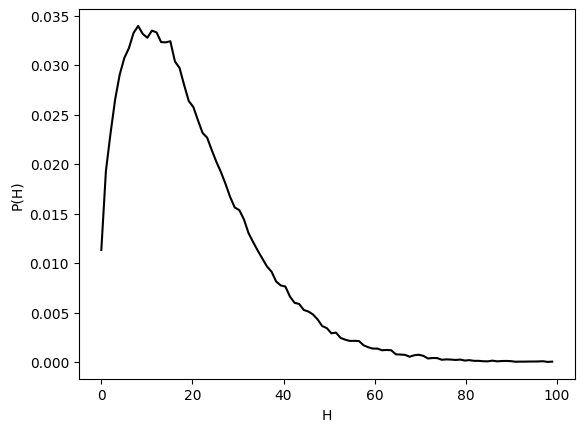

In [13]:
bins = np.linspace(0, 100, 100)
counts, _ = np.histogram(final_Hs_truth, bins=bins)
prob_dens = counts / np.sum(counts) / np.diff(bins)[0]

plt.figure()
plt.plot(bins[:-1], prob_dens, 'k-')
plt.xlabel('H')
plt.ylabel('P(H)')

Text(0, 0.5, '$H$')

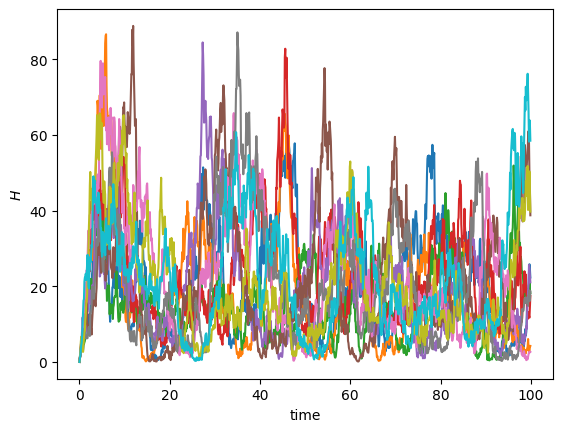

In [54]:
t_arr = torch.arange(0, t_max, dt)
plt.figure()
plt.plot(t_arr, H_arr_truth[:, :10])
plt.xlabel('time')
plt.ylabel('$H$')

## Try autograd

In [37]:
# Define simulation hyperparameters
num_simulations = 100000
num_iterations = 300

# fixed parameters
t_max = 100
dt = 0.1

# Initialize parameters --- assume gamma is known
r = torch.nn.Parameter(torch.tensor(8.0))
KD = torch.nn.Parameter(torch.tensor(9.0))
n =  torch.nn.Parameter(torch.tensor(1.5))
tau = torch.nn.Parameter(torch.tensor(5.0))
sigma =  torch.nn.Parameter(torch.tensor(1.6))
gamma = 0.23

# Define the Adam optimizer
optimizer = torch.optim.Adam([r, KD, n, tau, sigma], lr=0.01) #lr changed from 0.1

# Set target mean and standard deviation
target_mean = torch.mean(final_Hs_truth)
target_std = torch.std(final_Hs_truth)
lags = torch.arange(0, int(len(H_arr_truth) / 4), int(len(H_arr_truth) / 40))
lam = 1.0
target_corr = torch.mean(autocorr(H_arr_truth, lags), axis=1)

loss_history = []
param_history = []
# Loop through each iteration
for iteration in tqdm(range(num_iterations)):

    # Forward differentiable Gillespie simulation
    H_arr =  solve_sde_for_optimization(t_max=t_max, r=r, gamma=gamma, KD=KD, n=n, tau=tau, sigma=sigma, dt=dt, num_replicates=num_simulations)
    mean_final_state = torch.mean(H_arr[-1])
    variance = torch.var(H_arr[-1])
    corr = torch.mean(autocorr(H_arr, lags), axis=1)
    
    # Compute the loss for the current iteration
    loss = mean_var_autocorr_loss(mean_final_state, variance, corr, target_mean, target_std, target_corr, lam)

    # Zero the gradients to prepare for backward pass
    optimizer.zero_grad()

    # Compute the gradient of the loss with respect to parameters
    loss.backward()

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_([r, KD, n, tau, sigma], max_norm=0.2)

    # Update the parameters using the optimizer
    optimizer.step()
    
    # Clamp the parameter values to certain bounds
    r.data = torch.clamp(r.data, min=0.1, max=100.0)
    KD.data = torch.clamp(KD.data, min=1.0, max=1000.0)
    n.data = torch.clamp(n.data, min=0.1, max=100.0)
    tau.data = torch.clamp(tau.data, min=0.001, max=100.0)
    sigma.data = torch.clamp(sigma.data, min=0.001, max=10.0)
    
    if any([torch.isnan(p) for p in [r.data, KD.data, n.data, tau.data, sigma.data]]):
        raise ValueError
        
    loss_history.append(loss)
    param_history.append({'r': r.data, 'KD': KD.data, 'n': n.data, 'tau': tau.data, 'sigma': sigma.data})
    
print(f'r={r.data}, KD={KD.data}, n={n.data}, tau={tau.data}, sigma={sigma.data}')
#loss_history = [l.detach().numpy() for l in loss_history]
# for tensor in [KD, n, tau, sigma]:
#     param.detach()

100%|█████████████████████████████████████████| 300/300 [05:22<00:00,  1.08s/it]

r=9.639816284179688, KD=10.519267082214355, n=2.0066542625427246, tau=6.822580337524414, sigma=2.040149450302124


In [38]:
loss_history = [l.cpu().detach().numpy() for l in loss_history]

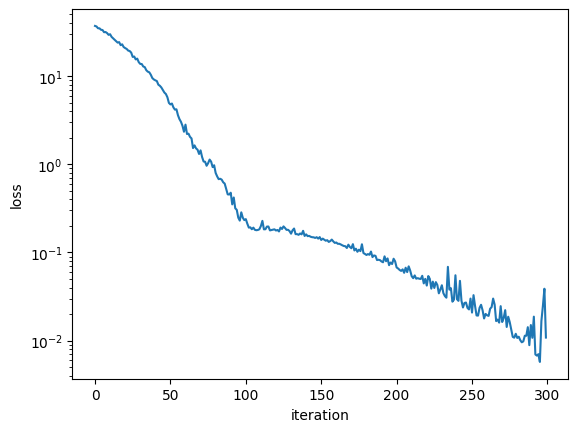

In [39]:
plt.figure()
plt.plot(loss_history)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.yscale('log')

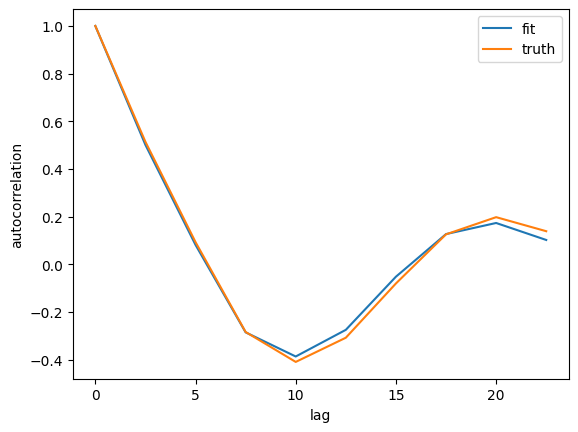

In [40]:
plt.figure()
plt.plot(lags.cpu() * dt, corr.cpu().detach().numpy(), label='fit')
plt.plot(lags.cpu() * dt, target_corr.cpu(), label='truth')
plt.xlabel('lag')
plt.ylabel('autocorrelation')
plt.legend()

In [41]:
print(f'mean error: {(mean_final_state - target_mean) ** 2}')
print(f'std error: {(variance ** 0.5 - target_std) ** 2}')
print(f'autocorr error: {lam * torch.sum((corr - target_corr) ** 2)}')

mean error: 0.005757203325629234
std error: 0.0004434026777744293
autocorr error: 0.004675026051700115


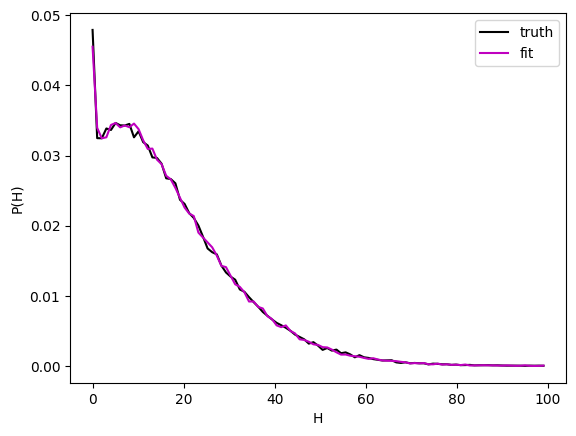

In [42]:
"""plot distribution overlay"""
plt.figure()
bins = np.linspace(0, 100, 100)

# ground truth
counts, _ = np.histogram(final_Hs_truth.cpu(), bins=bins)
prob_dens = counts / np.sum(counts) / np.diff(bins)[0]
plt.plot(bins[:-1], prob_dens, 'k-', label='truth')


# inferred
num_replicates = 100000
#H_arr_fit = solve_sde(t_max=t_max, KD=KD.data, n=n.data, tau=tau.data, sigma=sigma.data, dt=dt, num_replicates=num_replicates)
r_fit = param_history[-2]['r'].cpu()
KD_fit = param_history[-2]['KD'].cpu()
n_fit = param_history[-2]['n'].cpu()
tau_fit = tau#param_history[-2]['tau'].cpu()
sigma_fit = param_history[-2]['sigma'].cpu()

H_arr_fit = solve_sde(t_max=t_max, r=r_fit, KD=KD_fit, n=n_fit, tau=tau_fit, sigma=sigma_fit, dt=dt, num_replicates=num_replicates)

final_Hs_fit = H_arr_fit[-1]
counts, _ = np.histogram(final_Hs_fit.cpu(), bins=bins)
prob_dens = counts / np.sum(counts) / np.diff(bins)[0]

plt.plot(bins[:-1], prob_dens, 'm-', label='fit')
plt.xlabel('H')
plt.ylabel('P(H)')
plt.legend()

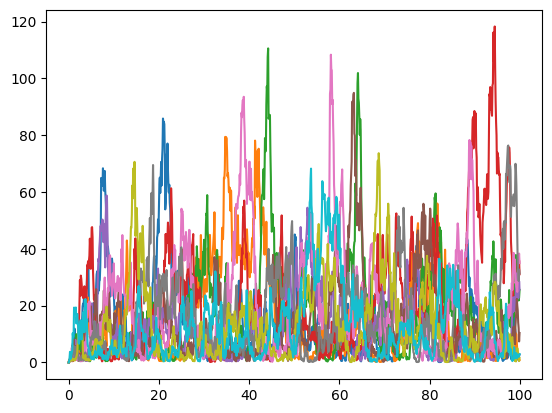

In [84]:
plt.figure()
plt.plot(t_arr, H_arr.detach().numpy()[:, :10])

## Diagnosing NaNs: trying fitting without delay

Seems to work!

In [14]:
"""testing stability without fitting delay"""
# Define simulation hyperparameters
num_simulations = 100000
num_iterations = 100

# fixed parameters
t_max = 100
dt = 0.1

# Initialize parameters --- assume gamma is known
r = torch.nn.Parameter(torch.tensor(8.0))
KD = torch.nn.Parameter(torch.tensor(9.0))
n =  torch.nn.Parameter(torch.tensor(1.5))
tau = torch.tensor([7.0])#torch.nn.Parameter(torch.tensor(5.0))
sigma =  torch.nn.Parameter(torch.tensor(1.6))
gamma = 0.23

# Define the Adam optimizer
optimizer = torch.optim.Adam([r, KD, n, sigma], lr=0.1) #lr changed from 0.1

# Set target mean and standard deviation
target_mean = torch.mean(final_Hs_truth)
target_std = torch.std(final_Hs_truth)
lags = torch.arange(0, int(len(H_arr_truth) / 4), int(len(H_arr_truth) / 40))
lam = 0#100.0
target_corr = torch.mean(autocorr(H_arr_truth, lags), axis=1)

loss_history = []
param_history = []
# Loop through each iteration
for iteration in tqdm(range(num_iterations)):

    # Forward differentiable Gillespie simulation
    H_arr =  solve_sde_for_optimization(t_max=t_max, r=r, gamma=gamma, KD=KD, n=n, tau=tau, sigma=sigma, dt=dt, num_replicates=num_simulations)
    if torch.sum(torch.isnan(H_arr[-1])) > 0:
        raise ValueError
    mean_final_state = torch.mean(H_arr[-1])
    variance = torch.var(H_arr[-1])
    corr = torch.mean(autocorr(H_arr, lags), axis=1)
    
    # Compute the loss for the current iteration
    loss = mean_var_autocorr_loss(mean_final_state, variance, corr, target_mean, target_std, target_corr, lam)

    # Zero the gradients to prepare for backward pass
    optimizer.zero_grad()

    # Compute the gradient of the loss with respect to parameters
    loss.backward()

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_([r, KD, n, sigma], max_norm=0.2)

    # Update the parameters using the optimizer
    optimizer.step()
    
    # Clamp the parameter values to certain bounds
    r.data = torch.clamp(r.data, min=0.1, max=100.0)
    KD.data = torch.clamp(KD.data, min=1.0, max=1000.0)
    n.data = torch.clamp(n.data, min=0.1, max=100.0)
    sigma.data = torch.clamp(sigma.data, min=0.001, max=10.0)
    
    if any([torch.isnan(p) for p in [r.data, KD.data, n.data, sigma.data]]):
        raise ValueError
        
    loss_history.append(loss)
    param_history.append({'r': r.data, 'KD': KD.data, 'n': n.data, 'sigma': sigma.data})
    
print(f'r={r.data}, KD={KD.data}, n={n.data}, sigma={sigma.data}')
#loss_history = [l.detach().numpy() for l in loss_history]
# for tensor in [KD, n, tau, sigma]:
#     param.detach()

100%|█████████████████████████████████████████| 100/100 [01:40<00:00,  1.01s/it]

r=9.30565071105957, KD=10.591211318969727, n=1.5666162967681885, sigma=2.1332151889801025


In [11]:
torch.sum(torch.isnan(H_arr[-1]))

tensor(0, device='cuda:0')

In [12]:
param_history[-1]

{'r': tensor(nan, device='cuda:0'),
 'KD': tensor(nan, device='cuda:0'),
 'n': tensor(nan, device='cuda:0'),
 'sigma': tensor(nan, device='cuda:0')}

In [4]:
t_max = 100.0
r = 9.3226
gamma = 0.23
KD = 10.5315
n = 1.5539
tau = 7.0
sigma = 2.1523
dt = 0.1
num_replicates = 100000
H_arr = solve_sde(t_max=t_max, r=r, gamma=gamma, KD=KD, n=n, tau=tau, sigma=sigma, dt=dt, num_replicates=num_replicates)
#H_arr = solve_sde_for_optimization(t_max=t_max, KD=KD, n=n, tau=tau, sigma=sigma, dt=dt, num_replicates=num_replicates)

In [5]:
torch.sum(torch.isnan(H_arr[-1]))

tensor(0, device='cuda:0')

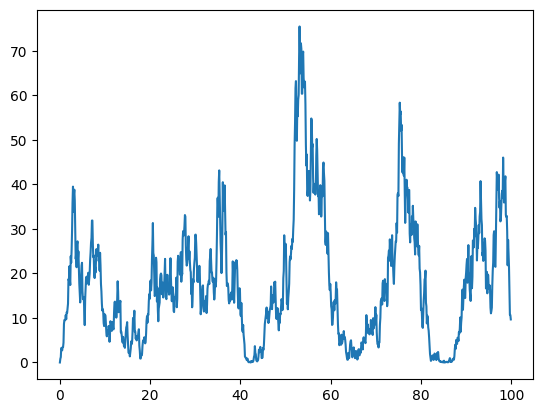

In [13]:
t_arr = np.arange(0, t_max, dt)
plt.figure()
plt.plot(t_arr, H_arr.cpu())

## Testing on Ozbudak data

In [103]:
df_dict = pd.read_excel(r'/home/brandon/Downloads/41586_2020_3055_MOESM7_ESM.xlsx', sheet_name=None)
df = df_dict['1']
sheet_numbers = np.arange(2, len(df_dict) + 1)
for n in sheet_numbers:
    df = pd.concat((df, df_dict[f'{n}']), axis=0)

her1 = df.get('her1.1').values
her1 = her1[~np.isnan(her1)]

Text(0, 0.5, 'probability_density')

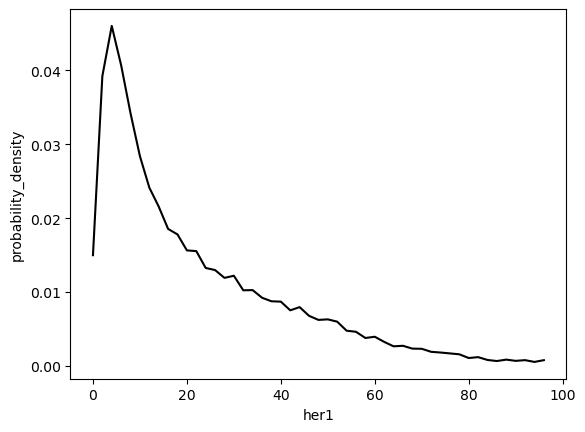

In [108]:
#bins = np.linspace(0, 1, 30
data_bins = np.arange(0, 100, 2)
counts, _ = np.histogram(her1, bins=data_bins)
prob_dens = counts / np.sum(counts) / np.diff(data_bins)[0]

plt.figure()
plt.plot(data_bins[:-1], prob_dens, 'k-')
plt.xlabel('her1')
plt.ylabel('probability_density')